# `sigvideo` 0.3.0 — Google Colab Test Notebook

**J. de Curtò and I. de Zarzà** — MIT License
https://github.com/drdecurto/sigvideo

> *Summarization of Videos with the Signature Transform*, Electronics 2023, 12, 1735.
> https://doi.org/10.3390/electronics12071735

---

### Sections
0. Install from wheel (upload manually) or from PyPI
1. **Real video** — download Big Buck Bunny, run the full pipeline ← start here
2. Primary API: `summarize_video()`
3. CLI: `sigvideo input.mp4 output.mp4`
4. Synthetic structured video (ground-truth verification)
5. Frame-level API and auto-length
6. Scoring
7. Parameter sensitivity
8. VLM text-conditioned pipeline (optional — `sigvideo[vlm]`)
9. Publication-style result figure

## 0 · Installation

Cell A: upload `sigvideo-0.3.0-py3-none-any.whl` via the file browser, then run.  
Cell B: install from PyPI once published.

**Signature order** — sigvideo 0.3.0 defaults to `sig_order=2` (0.6 ms/frame, fast).  
Pass `sig_order=3` to reproduce the paper exactly (70 ms/frame, 100x slower).

In [1]:
# Cell A — install from uploaded wheel
#!pip install /content/sigvideo-0.3.0-py3-none-any.whl -q

# Cell B — install from PyPI
!pip install sigvideo -q

import sigvideo
print('sigvideo', sigvideo.__version__)
print('authors :', sigvideo.__authors__)
print('license :', sigvideo.__license__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
sigvideo 0.3.0
authors : ['J. de Curtò', 'I. de Zarzà']
license : MIT


In [2]:
import os, shutil, random, time
import numpy as np
import cv2
from IPython.display import Video, display, HTML
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sigvideo import (
    summarize_video, write_summary_video,   # primary
    summarize, auto_length, extract_frames,  # frame-level
    rmse_signature_score, rmse_baseline, mean_signature, rmse, mae
)
print('All imports OK')

All imports OK


## 1 · Download a real video

We download a 90-second segment of **Big Buck Bunny** (Creative Commons, Blender Foundation)
directly from YouTube using `yt-dlp`, which is pre-installed in Colab.

If yt-dlp fails for any reason the cell falls back to the synthetic structured video
created in Section 4, so every subsequent cell still runs correctly.

In [3]:
# ── Download real video with yt-dlp (pre-installed in Colab) ────────────
import subprocess, os, cv2

REAL_VIDEO   = '/content/real_video.mp4'
REAL_FRAMES  = '/content/real_frames'
USE_REAL     = False   # set to True below if download succeeds

print('Installing / updating yt-dlp…')
subprocess.run(['pip', 'install', 'yt-dlp', '-q', '--upgrade'], check=False)

# Big Buck Bunny (official Blender channel, CC-BY)
YT_URL = 'https://www.youtube.com/watch?v=aqz-KE-bpKQ'

print(f'Downloading from {YT_URL} …')
tmp = '/content/_bbb_full.mp4'
r = subprocess.run(
    ['yt-dlp', '-q',
     '--format', 'best[ext=mp4][height<=480]/best[ext=mp4]/best',
     '--no-playlist',
     '-o', tmp, YT_URL],
    capture_output=True, text=True
)
if r.returncode != 0:
    print('yt-dlp stderr:', r.stderr[:300])

# Trim to 90 s with ffmpeg (already in Colab)
if os.path.isfile(tmp) and os.path.getsize(tmp) > 50_000:
    subprocess.run(
        ['ffmpeg', '-y', '-ss', '0', '-t', '90', '-i', tmp,
         '-c', 'copy', REAL_VIDEO, '-loglevel', 'quiet'],
        check=False
    )
    os.unlink(tmp)

# Validate
if os.path.isfile(REAL_VIDEO) and os.path.getsize(REAL_VIDEO) > 50_000:
    cap = cv2.VideoCapture(REAL_VIDEO)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    src_fps  = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    size_mb  = os.path.getsize(REAL_VIDEO) / 1e6
    if n_frames >= 20:
        USE_REAL = True
        print(f'Download OK  → {n_frames} frames @ {src_fps:.0f} fps  ({size_mb:.1f} MB)')
    else:
        print(f'Download produced only {n_frames} frames — will use synthetic fallback')
else:
    print('Download failed — will use synthetic fallback (Section 4 must run first)')

print(f'USE_REAL = {USE_REAL}')


Installing / updating yt-dlp…
Download OK  → 2701 frames @ 30 fps  (3.8 MB)
USE_REAL = True


## 2 · Primary pipeline — `summarize_video()`

One call: **video in → summarized video out**. H.264 output via ffmpeg.

```python
from sigvideo import summarize_video
summarize_video('input.mp4', 'summary.mp4')              # sig_order=2 (default, fast)
summarize_video('input.mp4', 'summary.mp4', sig_order=3) # paper-exact (100× slower)
```

[sigvideo] Video: real_video.mp4
[sigvideo] Source FPS: 30.00  |  Total frames: 2701
[sigvideo] Extracting every 30 frame(s) → ~1.00 fps
[sigvideo] Saved 91 frames to '/content/real_frames'.
[sigvideo] Auto-length search over: [4, 9, 13, 18, 22]
  length=   4: std=741.5  mean=5248.6
  length=   9: std=285.4  mean=3181.2
  length=  13: std=291.7  mean=2635.8
  length=  18: std=169.3  mean=2158.6
  length=  22: std=147.0  mean=2174.7

[sigvideo] Best length: 22  std=147.0  mean=2174.7
[sigvideo] Summary video (ffmpeg): 22 frames @ 2.0 fps = 11.0s → '/content/real_summary.mp4'

Input    : 90s   3668 KB
Summary  : 11.0s   655 KB
Keyframes: 22   (8.2x compression)
RMSE std : 147
Time     : 57s


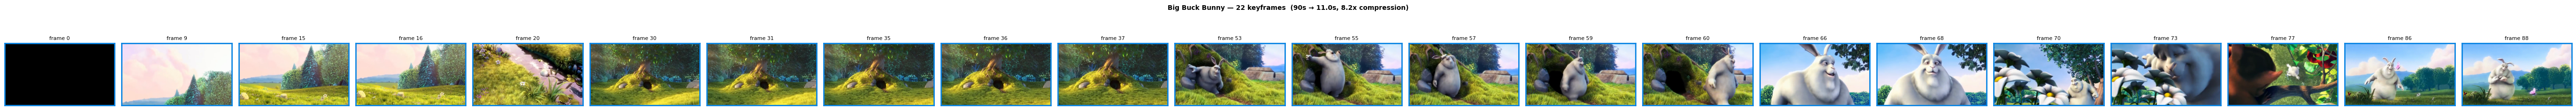

In [4]:
if not USE_REAL:
    print('Real video not available — see Section 4 for equivalent test.')
else:
    import time
    os.makedirs(REAL_FRAMES, exist_ok=True)
    REAL_SUMMARY = '/content/real_summary.mp4'

    t0 = time.time()
    real_out, real_selected, real_mean, real_std = summarize_video(
        input_video  = REAL_VIDEO,
        output_video = REAL_SUMMARY,
        summary_length = None,    # auto-detect best length
        n_candidates   = 10,
        n_comparisons  = 10,
        fps_extract    = 1.0,     # 1 frame/s extraction
        fps_output     = 2.0,     # each keyframe shown 0.5 s
        add_timestamp  = True,
        # sig_order=2 is the default — pass sig_order=3 for paper-exact
        keep_frames    = REAL_FRAMES,
        verbose        = True,
    )
    elapsed = time.time() - t0

    cap_in  = cv2.VideoCapture(REAL_VIDEO)
    cap_out = cv2.VideoCapture(REAL_SUMMARY)
    n_in    = int(cap_in.get(cv2.CAP_PROP_FRAME_COUNT))
    n_out_v = int(cap_out.get(cv2.CAP_PROP_FRAME_COUNT))
    dur_in  = n_in  / max(cap_in.get(cv2.CAP_PROP_FPS), 1)
    dur_out = n_out_v / max(cap_out.get(cv2.CAP_PROP_FPS), 1)
    cap_in.release(); cap_out.release()

    sep = '='*56
    print(f'\n{sep}')
    print(f'Input    : {dur_in:.0f}s   {os.path.getsize(REAL_VIDEO)//1024} KB')
    print(f'Summary  : {dur_out:.1f}s   {os.path.getsize(REAL_SUMMARY)//1024} KB')
    print(f'Keyframes: {len(real_selected)}   ({dur_in/max(dur_out,0.1):.1f}x compression)')
    print(f'RMSE std : {real_std:.0f}')
    print(f'Time     : {elapsed:.0f}s')
    print(sep)

    # Selected keyframes strip
    n_sel = len(real_selected)
    fig, axes = plt.subplots(1, n_sel, figsize=(2.5*n_sel, 2.8))
    if n_sel == 1: axes = [axes]
    for ax, fname in zip(axes, real_selected):
        img = cv2.imread(os.path.join(REAL_FRAMES, fname))
        if img is None: continue
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f'frame {int(fname.split("_")[1].split(".")[0])}', fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_edgecolor('#0984e3'); sp.set_linewidth(2)
    plt.suptitle(
        f'Big Buck Bunny — {n_sel} keyframes  '
        f'({dur_in:.0f}s → {dur_out:.1f}s, {dur_in/max(dur_out,0.1):.1f}x compression)',
        fontsize=10, fontweight='bold'
    )
    plt.tight_layout(); plt.show()

    # Play inline — H.264 output plays directly
    display(Video(REAL_SUMMARY, embed=True, width=480))


## 3 · CLI — `sigvideo input.mp4 output.mp4`

Runs on the real video if available, otherwise on the synthetic.  
Output is H.264 via ffmpeg. `sig_order=2` is the default (fast).

Use `--sig-order 3` to reproduce the paper's exact results.

In [5]:
import subprocess
_src = REAL_VIDEO if USE_REAL else '/content/sigvideo_synthetic.mp4'
print(f'CLI source: {_src}')

# Primary: auto-length (sig_order=2 is the default)
!sigvideo {_src} /content/cli_auto.mp4 \
          --fps-extract 1 --fps-output 2 \
          --n-candidates 5 --n-comparisons 5

# Fixed length, no timestamp
!sigvideo {_src} /content/cli_fixed.mp4 \
          --length 5 --fps-extract 1 --fps-output 2 --no-timestamp --quiet

# Paper-exact reproduction (slower)
# !sigvideo {_src} /content/cli_paper.mp4 --length 5 --sig-order 3 --quiet

# Verify outputs — check colour is correct
for path in ['/content/cli_auto.mp4', '/content/cli_fixed.mp4']:
    cap = cv2.VideoCapture(path)
    n   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    ret, frame = cap.read()
    cap.release()
    if ret:
        b, g, r = int(frame[...,0].mean()), int(frame[...,1].mean()), int(frame[...,2].mean())
        green_flag = '⚠ GREEN?' if (g > b+40 and g > r+40) else '✓ OK'
        print(f'{os.path.basename(path):20s}  {n} frames  avg BGR=({b},{g},{r})  {green_flag}')

print('\ncli_fixed.mp4:')
display(Video('/content/cli_fixed.mp4', embed=True, width=480))


CLI source: /content/real_video.mp4
[sigvideo] Video: real_video.mp4
[sigvideo] Source FPS: 30.00  |  Total frames: 2701
[sigvideo] Extracting every 30 frame(s) → ~1.00 fps
[sigvideo] Saved 91 frames to '/tmp/sigvideo_tmp_clkmsbhg'.
[sigvideo] Auto-length search over: [4, 9, 13, 18, 22]
  length=   4: std=434.5  mean=6479.0
  length=   9: std=392.5  mean=3263.3
  length=  13: std=182.8  mean=2904.7
  length=  18: std=192.5  mean=2697.2
  length=  22: std=222.4  mean=2180.3

[sigvideo] Best length: 13  std=182.8  mean=2904.7
[sigvideo] Summary video (ffmpeg): 13 frames @ 2.0 fps = 6.5s → '/content/cli_auto.mp4'

[sigvideo] 13 keyframes → '/content/cli_auto.mp4'
[sigvideo] RMSE  mean=2905  std=183
cli_auto.mp4          13 frames  avg BGR=(0,0,0)  ✓ OK
cli_fixed.mp4         5 frames  avg BGR=(125,171,171)  ✓ OK

cli_fixed.mp4:


## 4 · Synthetic structured video — ground-truth verification

6 scenes with known visual content so we can verify scene coverage:

| Scene | Content |
|-------|--------|
| A | Growing bright disk |
| B | Sweeping dark bar |
| C | Colour gradient |
| D | Checkerboard texture |
| E | Two merging blobs |
| F | Uniform grey (low-information) |

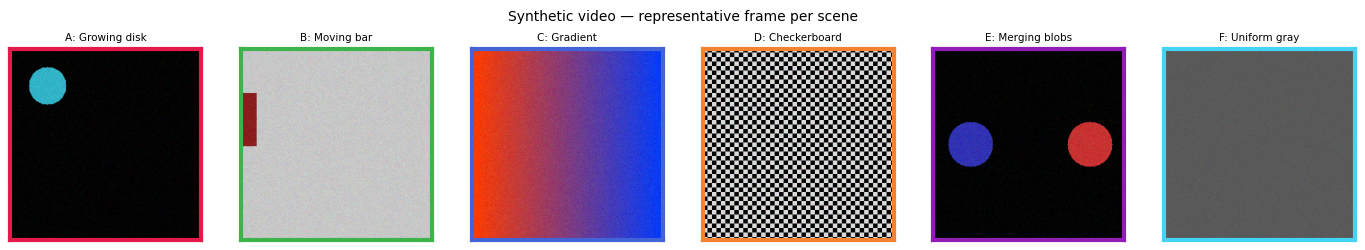

Synthetic video: 60 frames, 6 scenes x 10 frames each


In [6]:
H, W = 256, 256
np.random.seed(42)

def _noise(img, s=8):
    return np.clip(img.astype(float) + np.random.randn(*img.shape)*s, 0, 255).astype(np.uint8)

def _scene_A(i): img=np.zeros((H,W,3),dtype=np.uint8); cv2.circle(img,(50,50),25+i*2,(200,180,50),-1); return _noise(img)
def _scene_B(i): img=np.full((H,W,3),200,dtype=np.uint8); cv2.rectangle(img,(i*22,60),(i*22+20,130),(30,30,140),-1); return _noise(img)
def _scene_C(i):
    img=np.zeros((H,W,3),dtype=np.uint8)
    for c in range(W): img[:,c]=[int(255*c/W),60+i*8,255-int(255*c/W)]
    return _noise(img)
def _scene_D(i):
    cell=6+i*2; img=np.zeros((H,W,3),dtype=np.uint8)
    for r in range(H):
        for c in range(W):
            if ((r//cell)+(c//cell))%2==0: img[r,c]=[220,220,220]
    return _noise(img)
def _scene_E(i):
    img=np.zeros((H,W,3),dtype=np.uint8)
    cv2.circle(img,(50+i*10,128),30,(180,50,50),-1); cv2.circle(img,(210-i*10,128),30,(50,50,200),-1)
    return _noise(img)
def _scene_F(i): return _noise(np.full((H,W,3),90+i*5,dtype=np.uint8),s=4)

SCENE_COLORS={'A':'#e6194b','B':'#3cb44b','C':'#4363d8','D':'#f58231','E':'#911eb4','F':'#42d4f4'}
SCENE_LABELS={'A':'Growing disk','B':'Moving bar','C':'Gradient','D':'Checkerboard','E':'Merging blobs','F':'Uniform gray'}
SCENE_FUNCS={'A':_scene_A,'B':_scene_B,'C':_scene_C,'D':_scene_D,'E':_scene_E,'F':_scene_F}

SYN_VIDEO  = '/content/sigvideo_synthetic.mp4'
SYN_FRAMES = '/content/syn_frames'
os.makedirs(SYN_FRAMES, exist_ok=True)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(SYN_VIDEO, fourcc, 5.0, (W,H))
frame_scene_map = {}  # global frame_index -> scene label
fidx = 0
for sc, fn in SCENE_FUNCS.items():
    for i in range(10):
        frame = fn(i)
        writer.write(frame)
        fname = f'frame_{fidx:04d}.png'
        cv2.imwrite(os.path.join(SYN_FRAMES, fname), frame)
        frame_scene_map[fidx] = sc
        fidx += 1
writer.release()

# Preview
fig, axes = plt.subplots(1, 6, figsize=(14, 2.5))
for ax, sc in zip(axes, 'ABCDEF'):
    idx = 'ABCDEF'.index(sc) * 10
    img = cv2.cvtColor(cv2.imread(os.path.join(SYN_FRAMES, f'frame_{idx:04d}.png')), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f'{sc}: {SCENE_LABELS[sc]}', fontsize=7.5)
    for sp in ax.spines.values(): sp.set_edgecolor(SCENE_COLORS[sc]); sp.set_linewidth(3)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Synthetic video — representative frame per scene', fontsize=10)
plt.tight_layout(); plt.show()
print(f'Synthetic video: {fidx} frames, 6 scenes x 10 frames each')

In [7]:
# Run summarize_video() on the synthetic video
# sig_order=2 is the default — no need to pass it explicitly
random.seed(0); np.random.seed(0)
t0 = time.time()

syn_out, syn_selected, syn_mean, syn_std = summarize_video(
    SYN_VIDEO, '/content/syn_summary.mp4',
    summary_length=12, n_candidates=20, n_comparisons=10,
    fps_extract=5.0, fps_output=2.0, add_timestamp=True,
    # sig_order=3 to reproduce paper exactly
    keep_frames=SYN_FRAMES,
    verbose=True,
)
print(f'\nTime: {time.time()-t0:.1f}s')

def scene_of(fname):
    return frame_scene_map.get(int(fname.split('_')[1].split('.')[0]), '?')

counts  = {s: sum(scene_of(f)==s for f in syn_selected) for s in 'ABCDEF'}
covered = sum(1 for v in counts.values() if v > 0)
print(f'Frames per scene: {counts}')
print(f'Scenes covered  : {covered}/6')
assert len(syn_selected)==12 and len(set(syn_selected))==12, 'Frame count error'
print('summarize_video() on synthetic video ✓')


[sigvideo] Video: sigvideo_synthetic.mp4
[sigvideo] Source FPS: 5.00  |  Total frames: 60
[sigvideo] Extracting every 1 frame(s) → ~5.00 fps
[sigvideo] Saved 60 frames to '/content/syn_frames'.
[sigvideo] Found 120 frames in '/content/syn_frames'.
[sigvideo] Evaluating 20 candidates of length 12...
  Candidate  1/20: std=1048.4  mean=1670.7
  Candidate  2/20: std=1258.3  mean=1082.9
  Candidate  3/20: std=506.6  mean=2742.2
  Candidate  4/20: std=618.4  mean=2577.1
  Candidate  5/20: std=975.7  mean=1084.6
  Candidate  6/20: std=791.3  mean=2029.8
  Candidate  7/20: std=942.0  mean=1520.4
  Candidate  8/20: std=770.4  mean=819.7
  Candidate  9/20: std=590.5  mean=2395.5
  Candidate 10/20: std=940.7  mean=1982.3
  Candidate 11/20: std=475.8  mean=2395.5
  Candidate 12/20: std=447.4  mean=3129.2
  Candidate 13/20: std=924.9  mean=2085.2
  Candidate 14/20: std=984.6  mean=3177.6
  Candidate 15/20: std=1007.9  mean=1398.0
  Candidate 16/20: std=1021.6  mean=1414.2
  Candidate 17/20: std=72

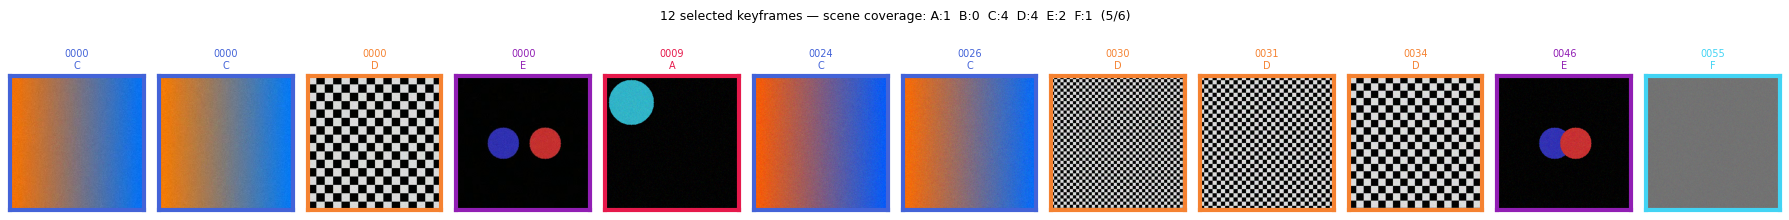

In [8]:
# Keyframe strip with scene colours
fig, axes = plt.subplots(1, 12, figsize=(18, 2.5))
for ax, fname in zip(axes, syn_selected):
    img = cv2.cvtColor(cv2.imread(os.path.join(SYN_FRAMES, fname)), cv2.COLOR_BGR2RGB)
    sc  = scene_of(fname)
    ax.imshow(img)
    ax.set_title(f'{fname[6:10]}\n{sc}', fontsize=7, color=SCENE_COLORS.get(sc, 'k'))
    for sp in ax.spines.values(): sp.set_edgecolor(SCENE_COLORS.get(sc,'k')); sp.set_linewidth(3)
    ax.set_xticks([]); ax.set_yticks([])
counts_str = '  '.join(f'{k}:{v}' for k,v in counts.items())
plt.suptitle(f'12 selected keyframes — scene coverage: {counts_str}  ({covered}/6)', fontsize=9)
plt.tight_layout(); plt.show()

## 5 · Frame-level API and auto-length

In [9]:
# Use real frames if available, otherwise synthetic
DEMO_FRAMES = REAL_FRAMES if (USE_REAL and os.path.isdir(REAL_FRAMES)) else SYN_FRAMES
print(f'Using frames from: {DEMO_FRAMES}')

random.seed(1); np.random.seed(1)
best_len, al_frames, al_mean, al_std = auto_length(
    DEMO_FRAMES,
    length_range=[3, 5, 7, 9],
    n_candidates=10, n_comparisons=10,
    verbose=True,
)
print(f'\nAuto-selected length: {best_len}')

# Build a summary video from those frames
al_paths = [os.path.join(DEMO_FRAMES, f) for f in al_frames]
write_summary_video(al_paths, '/content/manual_summary.mp4',
                    fps_output=2.0, add_timestamp=True, verbose=True)


Using frames from: /content/real_frames
[sigvideo] Auto-length search over: [3, 5, 7, 9]
  length=   3: std=617.8  mean=7573.5
  length=   5: std=396.5  mean=7466.0
  length=   7: std=385.1  mean=3360.4
  length=   9: std=401.6  mean=2985.4

[sigvideo] Best length: 7  std=385.1  mean=3360.4

Auto-selected length: 7
[sigvideo] Summary video (ffmpeg): 7 frames @ 2.0 fps = 3.5s → '/content/manual_summary.mp4'


'/content/manual_summary.mp4'

  L= 3  std=467  mean=5085
  L= 5  std=617  mean=4593
  L= 7  std=408  mean=3080
  L= 9  std=279  mean=3368


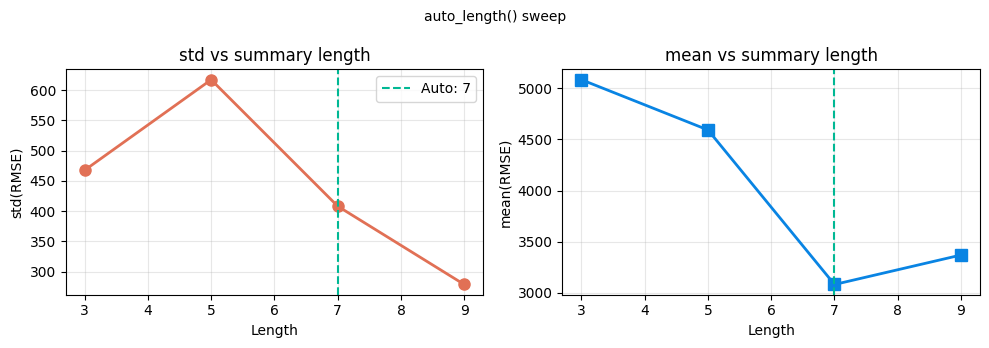

In [10]:
# std vs length sweep
lengths = [3, 5, 7, 9]
stds, means = [], []
for L in lengths:
    random.seed(42); np.random.seed(42)
    all_pngs = [f for f in os.listdir(DEMO_FRAMES) if f.endswith('.png')]
    if L > len(all_pngs): continue
    _, m, s = summarize(DEMO_FRAMES, L, n_candidates=8, n_comparisons=8, verbose=False)
    stds.append(s); means.append(m)
    print(f'  L={L:2d}  std={s:.0f}  mean={m:.0f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.plot(lengths[:len(stds)], stds, 'o-', color='#e17055', lw=2, ms=8)
ax1.axvline(best_len, color='#00b894', lw=1.5, ls='--', label=f'Auto: {best_len}')
ax1.set_xlabel('Length'); ax1.set_ylabel('std(RMSE)')
ax1.set_title('std vs summary length'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(lengths[:len(means)], means, 's-', color='#0984e3', lw=2, ms=8)
ax2.axvline(best_len, color='#00b894', lw=1.5, ls='--')
ax2.set_xlabel('Length'); ax2.set_ylabel('mean(RMSE)')
ax2.set_title('mean vs summary length'); ax2.grid(alpha=0.3)
plt.suptitle('auto_length() sweep', fontsize=10)
plt.tight_layout(); plt.show()


## 6 · Scoring — `rmse_signature_score()` and `rmse_baseline()`

RMSE(S̄,S̄*)  mean=    2,889   std=      804
RMSE(S̄,S̄)   mean=    2,441   std=      970
Verdict : PASS


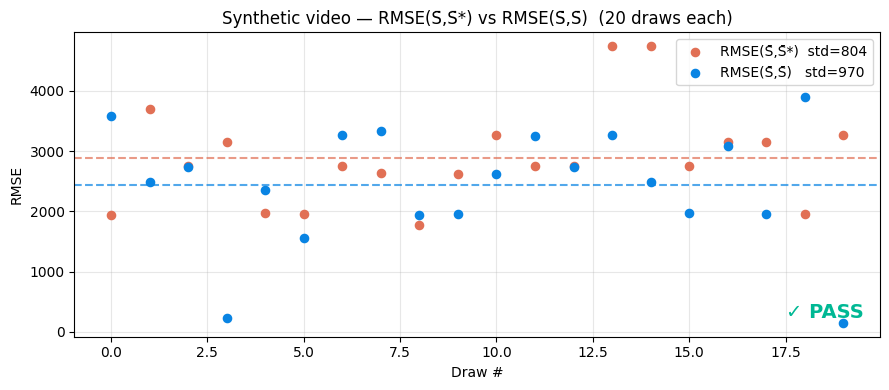

In [11]:
# Always use the synthetic summary (guaranteed to be set in Section 4)
ALL_FRAMES_PATHS = sorted(
    os.path.join(SYN_FRAMES, f)
    for f in os.listdir(SYN_FRAMES) if f.endswith('.png')
)
SUM_PATHS = [os.path.join(SYN_FRAMES, f) for f in syn_selected]

vals_star, mean_star, std_star = rmse_signature_score(
    SUM_PATHS, ALL_FRAMES_PATHS, n_comparisons=20
)
vals_base, base_mean, base_std = rmse_baseline(
    ALL_FRAMES_PATHS, summary_length=len(SUM_PATHS), n_comparisons=20
)

verdict = 'PASS' if std_star <= base_std else 'FAIL'
sep = '='*52
print(sep)
print(f'RMSE(S\u0304,S\u0304*)  mean={mean_star:>9,.0f}   std={std_star:>9,.0f}')
print(f'RMSE(S\u0304,S\u0304)   mean={base_mean:>9,.0f}   std={base_std:>9,.0f}')
print(f'Verdict : {verdict}')
print(sep)

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(range(len(vals_star)), vals_star, c='#e17055', s=35, zorder=3,
           label=f'RMSE(S\u0304,S\u0304*)  std={std_star:.0f}')
ax.scatter(range(len(vals_base)), vals_base, c='#0984e3', s=35, zorder=3,
           label=f'RMSE(S\u0304,S\u0304)   std={base_std:.0f}')
ax.axhline(mean_star, color='#e17055', lw=1.5, ls='--', alpha=0.7)
ax.axhline(base_mean, color='#0984e3', lw=1.5, ls='--', alpha=0.7)
ax.set_title('Synthetic video — RMSE(S\u0304,S\u0304*) vs RMSE(S\u0304,S\u0304)  (20 draws each)')
ax.set_xlabel('Draw #'); ax.set_ylabel('RMSE'); ax.legend(); ax.grid(alpha=0.3)
vc = '#00b894' if std_star <= base_std else '#d63031'
vt = '\u2713 PASS' if std_star <= base_std else '\u2717 FAIL'
ax.text(0.98, 0.05, vt, transform=ax.transAxes,
        ha='right', va='bottom', fontsize=14, color=vc, fontweight='bold')
plt.tight_layout(); plt.show()


## 7 · Parameter sensitivity

In [12]:
print(f'Sensitivity on: {DEMO_FRAMES}')
print('n_candidates sweep (sig_order=2, length=5):')
for nc in [3, 5, 10, 20]:
    random.seed(42); np.random.seed(42)
    _, m, s = summarize(DEMO_FRAMES, 5, n_candidates=nc, n_comparisons=8, verbose=False)
    print(f'  n_candidates={nc:2d}  std={s:,.0f}  mean={m:,.0f}')

print('\nSignature order — default (2) vs paper-exact (3):')
for order, label in [(2, 'default — fast'), (3, 'paper exact — slow')]:
    random.seed(42); np.random.seed(42)
    t0 = time.time()
    _, m, s = summarize(DEMO_FRAMES, 5, n_candidates=5, n_comparisons=8,
                        order=order, verbose=False)
    elapsed = time.time() - t0
    print(f'  order={order}  std={s:,.0f}  mean={m:,.0f}  time={elapsed:.1f}s  [{label}]')


Sensitivity on: /content/real_frames
n_candidates sweep (sig_order=2, length=5):
  n_candidates= 3  std=764  mean=4,089
  n_candidates= 5  std=617  mean=4,593
  n_candidates=10  std=617  mean=4,593
  n_candidates=20  std=418  mean=4,758

Signature order — default (2) vs paper-exact (3):
  order=2  std=617  mean=4,593  time=1.3s  [default — fast]
  order=3  std=61,940  mean=444,919  time=15.6s  [paper exact — slow]


## 8 · VLM text-conditioned pipeline (optional)

Requires `pip install sigvideo[vlm]` (adds `torch`, `transformers`, `nltk`, `Pillow`).

After installing, download NLTK data once:
```python
import nltk
for r in ['punkt','punkt_tab','stopwords',
          'averaged_perceptron_tagger','averaged_perceptron_tagger_eng']:
    nltk.download(r, quiet=True)
```
Then run from CLI:
```bash
sigvideo vlm --frames-dir /content/real_frames \
             --subtitles transcript.txt --output summary_vlm.txt
```
The cell below tests the NLP stage only (no GPU needed).

In [13]:
!pip install sigvideo[vlm] -q

import nltk
for resource in ['punkt','punkt_tab','stopwords',
                 'averaged_perceptron_tagger','averaged_perceptron_tagger_eng']:
    nltk.download(resource, quiet=True)

from sigvideo.vlm import extract_noun_queries

TRANSCRIPT = """
Watch as fire crews battle the massive blaze engulfing the building.
The smoke billows into the sky as firefighters aim their hoses at the flame.
Water jets strike the wall of fire while emergency vehicles surround the structure.
Flames leap from window to window as the crew works to contain the fire.
"""

queries = extract_noun_queries(TRANSCRIPT, top_n=12)
print(f'Extracted {len(queries)} noun queries:')
print(queries)
print()
print('Full OWL-ViT pipeline (GPU recommended):')
print('  from sigvideo.vlm import summarize_vlm')
print('  frames = summarize_vlm(real_frames, queries, score_threshold=0.025)')


Extracted 11 noun queries:
['fire', 'window', 'battle', 'blaze', 'building', 'smoke', 'flame', 'wall', 'emergency', 'structure', 'crew']

Full OWL-ViT pipeline (GPU recommended):
  from sigvideo.vlm import summarize_vlm
  frames = summarize_vlm(real_frames, queries, score_threshold=0.025)


## 9 · Publication-style summary figure

Reproduces Figure 1 of the paper using the synthetic video data (always available).
Uses `syn_selected` from Section 4 and `SYN_FRAMES`.

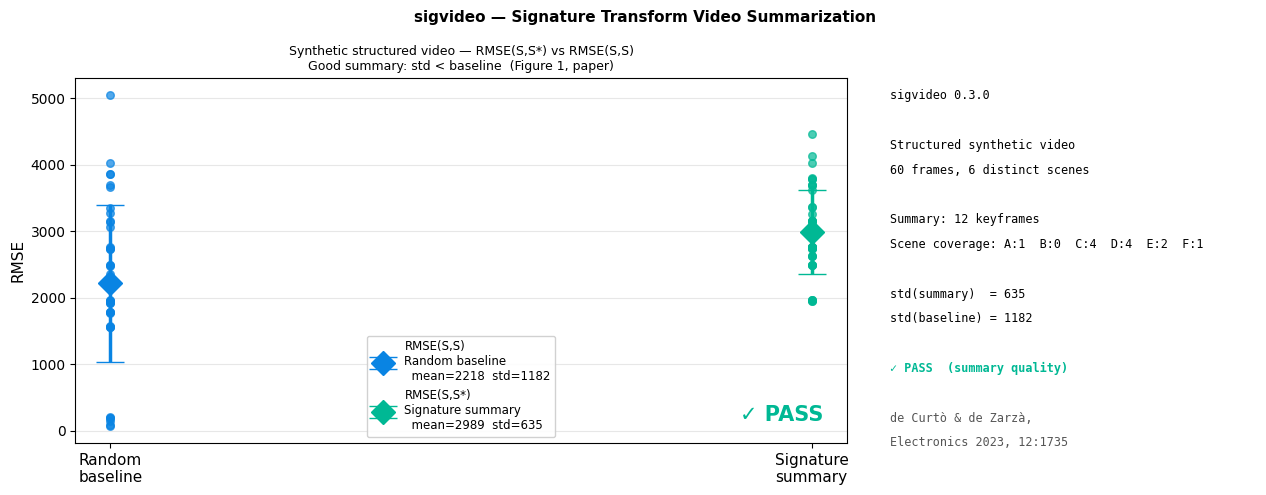

Verdict: ✓ PASS


In [14]:
random.seed(7); np.random.seed(7)

# Always use synthetic data — guaranteed to be set in Section 4
good_paths = [os.path.join(SYN_FRAMES, f) for f in syn_selected]
good_sig   = mean_signature(good_paths)

draws_vs_good, draws_vs_rand = [], []
for _ in range(40):
    d = random.sample(ALL_FRAMES_PATHS, len(good_paths))
    m = mean_signature(d)
    if m is not None:
        draws_vs_good.append(rmse(m, good_sig))
    d1, d2 = (random.sample(ALL_FRAMES_PATHS, len(good_paths)),
              random.sample(ALL_FRAMES_PATHS, len(good_paths)))
    m1, m2 = mean_signature(d1), mean_signature(d2)
    if (m1 is not None) and (m2 is not None):
        draws_vs_rand.append(rmse(m1, m2))

good_pass = np.std(draws_vs_good) <= np.std(draws_vs_rand)
vt = '\u2713 PASS' if good_pass else '\u2717 FAIL'
vc = '#00b894' if good_pass else '#d63031'

fig, (ax_main, ax_card) = plt.subplots(
    1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [2, 1]}
)

for pos, d, c, lbl in [
    (1, draws_vs_rand, '#0984e3', 'RMSE(S\u0304,S\u0304)\nRandom baseline'),
    (2, draws_vs_good, '#00b894', 'RMSE(S\u0304,S\u0304*)\nSignature summary'),
]:
    ax_main.scatter([pos]*len(d), d, color=c, s=30, zorder=3, alpha=0.7)
    ax_main.errorbar(pos, np.mean(d), yerr=np.std(d), fmt='D', color=c,
                     ms=12, lw=2.5, capsize=10,
                     label=f'{lbl}\n  mean={np.mean(d):.0f}  std={np.std(d):.0f}')

ax_main.set_xticks([1, 2])
ax_main.set_xticklabels(['Random\nbaseline', 'Signature\nsummary'], fontsize=11)
ax_main.set_ylabel('RMSE', fontsize=11)
ax_main.set_title(
    'Synthetic structured video — RMSE(S\u0304,S\u0304*) vs RMSE(S\u0304,S\u0304)\n'
    'Good summary: std < baseline  (Figure 1, paper)',
    fontsize=9
)
ax_main.legend(fontsize=8.5, framealpha=0.9)
ax_main.grid(axis='y', alpha=0.3)
ax_main.text(0.97, 0.05, vt, transform=ax_main.transAxes,
             ha='right', va='bottom', fontsize=15, color=vc, fontweight='bold')

ax_card.axis('off')
counts_str = '  '.join(f'{k}:{v}' for k, v in
                       {s: sum(scene_of(f)==s for f in syn_selected) for s in 'ABCDEF'}.items())
lines = [
    'sigvideo 0.3.0',
    '',
    'Structured synthetic video',
    '60 frames, 6 distinct scenes',
    '',
    f'Summary: {len(syn_selected)} keyframes',
    f'Scene coverage: {counts_str}',
    '',
    f'std(summary)  = {np.std(draws_vs_good):.0f}',
    f'std(baseline) = {np.std(draws_vs_rand):.0f}',
    '',
    vt + '  (summary quality)',
    '',
    'de Curt\u00f2 & de Zarz\u00e0,',
    'Electronics 2023, 12:1735',
]
for k, line in enumerate(lines):
    col = ('#00b894' if '\u2713' in line
           else '#d63031' if '\u2717' in line
           else '#555' if ('Curt' in line or 'Electron' in line) else 'black')
    fw = 'bold' if ('\u2713' in line or '\u2717' in line) else 'normal'
    ax_card.text(0.05, 0.97 - k*0.068, line,
                 transform=ax_card.transAxes, fontsize=8.5,
                 va='top', color=col, fontweight=fw, fontfamily='monospace')

plt.suptitle('sigvideo — Signature Transform Video Summarization',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sigvideo_result.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Verdict: {vt}')


## Clean up

In [ ]:
import shutil
for p in ['/content/real_video.mp4', '/content/real_summary.mp4',
          '/content/_bbb_full.mp4',
          '/content/sigvideo_synthetic.mp4', '/content/syn_summary.mp4',
          '/content/cli_auto.mp4', '/content/cli_fixed.mp4',
          '/content/manual_summary.mp4', '/content/sigvideo_result.png']:
    try: os.unlink(p)
    except: pass
for d in ['/content/real_frames', '/content/syn_frames']:
    shutil.rmtree(d, ignore_errors=True)
print('Cleaned up.')
print('\n=== sigvideo 0.3.0 — all Colab tests complete ===')


---
## Reference
```bibtex
@article{sigvideodecurto2023,
  title   = {Summarization of Videos with the Signature Transform},
  author  = {de Curt\`o, J. and de Zarz\`a, I. and Roig, G. and Calafate, C.T.},
  journal = {Electronics},
  volume  = {12}, number = {7}, pages = {1735}, year = {2023},
  doi     = {10.3390/electronics12071735}
}
```
MIT License — Copyright (c) 2023 J. de Curtò and I. de Zarzà
https://github.com/drdecurto/sigvideo